00_baseline.ipynb: the control. We run the original sleep-like sequence input first, before adding burst regimes.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Let this notebook import from src/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.inputs import make_sleep_like_sequence
from src.dendrite import (
    simulate_dendrite,
    activation_times,
    score_detection,
    print_score,
    plot_input_raster,
    plot_voltage_traces,
    plot_ampa_conductances,
    plot_nmda_conductances,
)

Setup

In [ ]:
n_segments = 12
sequence_segments = [5, 6, 7, 8]

T = 80.0
dt = 0.02

G_NMDA = 20.0
G_KIR = 20.0
G_ax = 1.0

input

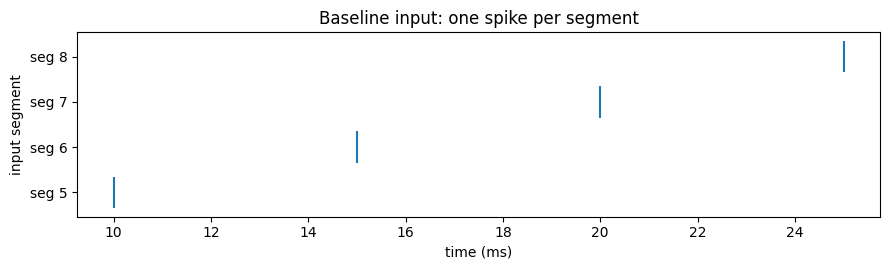

In [ ]:
events, raster = make_sleep_like_sequence(
    sequence_segments=sequence_segments,
    start_time=10.0,
    step_ms=5.0,
    weight=1.0,
)

plot_input_raster(raster, title="Baseline input: one spike per segment")

run simulation

In [ ]:
times, V_hist = simulate_dendrite(
    n_segments=n_segments,
    T=T,
    dt=dt,
    G_NMDA=G_NMDA,
    G_KIR=G_KIR,
    G_ax=G_ax,
    ampa_events=events,
)

and finally... our results

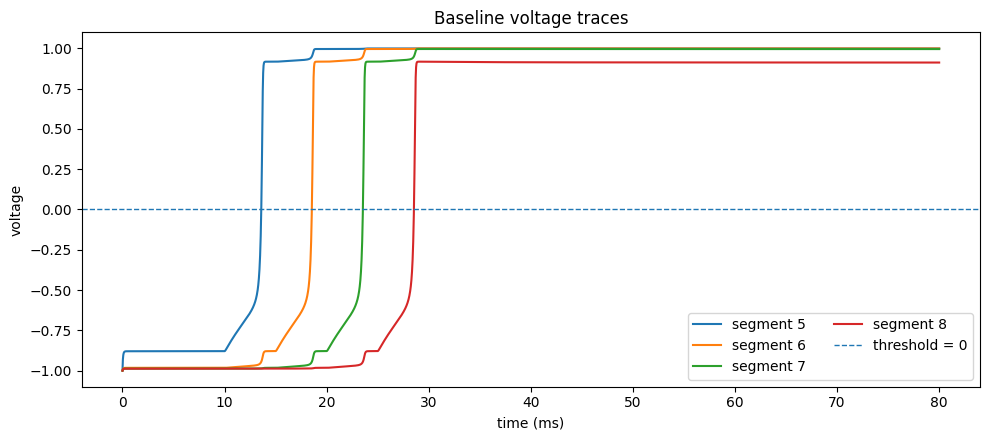

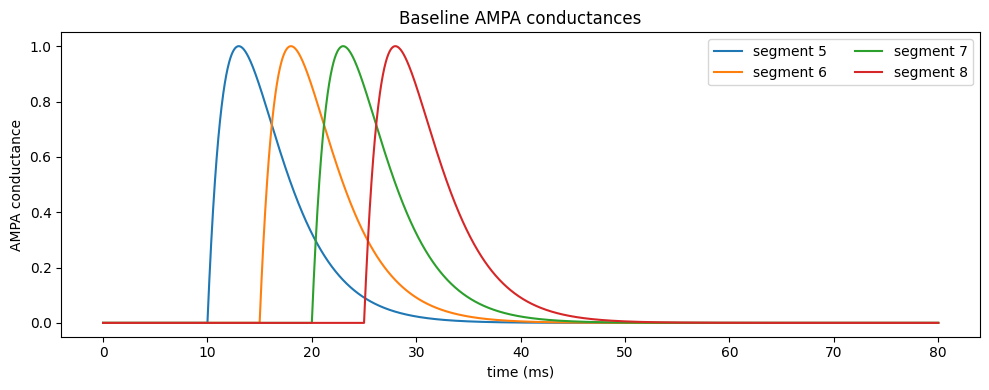

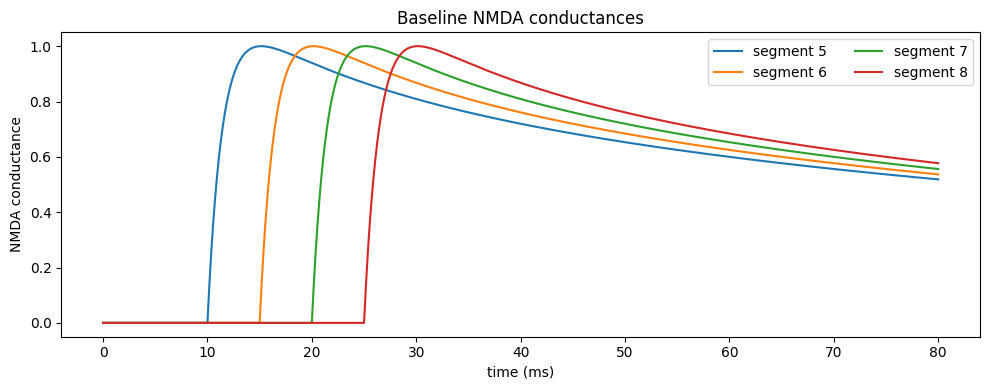

In [ ]:
plot_voltage_traces(
    times,
    V_hist,
    segments_to_plot=sequence_segments,
    title="Baseline voltage traces",
)

plot_ampa_conductances(
    times,
    n_segments,
    events,
    title="Baseline AMPA conductances",
)

plot_nmda_conductances(
    times,
    n_segments,
    events,
    title="Baseline NMDA conductances",
)

## Score detection

This checks whether the sequence segments cross threshold in order and whether the last segment stays high.

In [ ]:
score = score_detection(
    times,
    V_hist,
    sequence_segments=sequence_segments,
    threshold=0.0,
)

print_score(score)

success: True
all_detected: True
ordered: True
final_high: True
final_voltage: 0.912
activation_times: {5: 13.6, 6: 18.56, 7: 23.56, 8: 28.560000000000002}


## Quick check

In [ ]:
if score["success"]:
    print("Baseline works: the clean one-spike sequence was detected.")
else:
    print("Baseline failed: adjust timing or conductance values before testing bursts.")

Baseline works: the clean one-spike sequence was detected.
